<a href="https://colab.research.google.com/github/caniletgo/ML/blob/main/%D0%9B%D0%A0_2_2_%D0%9C%D0%9D_%D0%A7%D0%B5%D1%80%D0%BD%D0%B8%D1%88_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [4]:
df =  pd.read_csv(os.path.join(path, "titanic.csv"))

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**PassengerId:** Унікальний ідентифікатор для кожного пасажира.

**Survived:** У цьому стовпці вказується, чи вижив пасажир (1), чи ні (0).

**Pclass (Клас квитка):** Показник соціально-економічного статусу, де 1 – найвищий
клас, а 3 – найнижчий.

**Name:** Ім'я пасажира.

**Sex:** Стать пасажира.

**Age:** Вік пасажира. (Примітка: У цьому стовпці можуть бути відсутні значення.)

**SibSp:** Кількість братів і сестер або подружжя пасажира на борту «Титаніка».

**Parch:** Кількість батьків або дітей пасажира на борту «Титаніка».

**Ticket:** Номер квитка.

**Fare:** Сума грошей, яку пасажир сплатив за квиток.

**Основна мета використання цього набору даних** — передбачити, чи вижив пасажир, на основі різних характеристик. Він є популярним вступним набором даних для тих, хто вивчає аналіз даних, машинне навчання та прогностичне моделювання. Варто пам’ятати, що цей набір даних може змінюватися й оновлюватися, тому для отримання найактуальнішої інформації завжди варто перевіряти вебсайт Kaggle або документацію до набору даних.

2. Визначити розмір датасета.
3. Визначити тип даних.

In [5]:
print(f"Кількість рядків: {df.shape[0]}, кількість стовпців: {df.shape[1]}")
df.shape

Кількість рядків: 891, кількість стовпців: 12


(891, 12)

In [6]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


4. Визначити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [11]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

df.drop(columns=['Cabin', 'Embarked'], errors='ignore', inplace=True)

5. Ще раз перевірити наявність пропущених значень.

In [15]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


6. Сформувати датасет з обраними стовпцями: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

In [16]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


7. Замінити бінарні ознаки (Стать) на 0 і 1 (але перевірте унікальні значення даного стовпчика). Буває, що є середня стать)

In [17]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [18]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(f'Data types of the dataset:\n{df.dtypes}')

Data types of the dataset:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


/tmp/ipykernel_1228/275882515.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


8. Вивести описову статистику датасету describe()

In [19]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


9. Ще раз перевірити кількість пропущених даних (впевнитись, що їх немає).

In [20]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


10. Вивести 5 перших рядків датасету.

In [21]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500



11. Вивести 5 останніх рядків датасету.

In [22]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


12. Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?

In [23]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

print(f'share of survived males: {survival_by_sex[0]:.2f}%')
print(f'Share of survived females: {survival_by_sex[1]:.2f}%')

share of survived males: 18.89%
Share of survived females: 74.20%


In [24]:
print(f'Correlation between sex and survival: {df["Sex"].corr(df["Survived"])}')

Correlation between sex and survival: 0.5433513806577555


 13. Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?

In [25]:
class1_surv_rate = df[(df['Pclass'] == 1) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 1].shape[0]
class2_surv_rate = df[(df['Pclass'] == 2) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 2].shape[0]
class3_surv_rate = df[(df['Pclass'] == 3) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 3].shape[0]

print(f'Share of survived class 1 passengers {class1_surv_rate * 100:.2f}%')
print(f'Share of survived class 2 passengers {class2_surv_rate * 100:.2f}%')
print(f'Share of survived class 3 passengers {class3_surv_rate * 100:.2f}%')

Share of survived class 1 passengers 62.96%
Share of survived class 2 passengers 47.28%
Share of survived class 3 passengers 24.24%


14.  Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?

In [26]:
survived_mean_age = df[df['Survived'] == 1]['Age'].mean()
not_survived_mean_age = df[df['Survived'] == 0]['Age'].mean()

print(f'Mean age of survived passengers: {survived_mean_age:.2f}')
print(f'Mean age of not survived passengers: {not_survived_mean_age:.2f}')

Mean age of survived passengers: 28.29
Mean age of not survived passengers: 30.03


 15. Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?

In [27]:
df['Fare_Category'] = pd.qcut(df['Fare'], q=6, labels=False)
for i in range(6):
  surv_rate = df[(df['Fare_Category'] == i) & (df['Survived'] == 1)].shape[0] / df[df['Fare_Category'] == i].shape[0]
  print(f'Shape of survived passengers in bucket {i}: {surv_rate * 100:.2f}%')

Shape of survived passengers in bucket 0: 20.51%
Shape of survived passengers in bucket 1: 19.08%
Shape of survived passengers in bucket 2: 36.69%
Shape of survived passengers in bucket 3: 43.62%
Shape of survived passengers in bucket 4: 41.78%
Shape of survived passengers in bucket 5: 69.80%


/tmp/ipykernel_1228/1515389469.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_Category'] = pd.qcut(df['Fare'], q=6, labels=False)


Можна помітити, що пасажири з дорожчими квитками мали вищі шанси на виживання.

 16. Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?

In [28]:
for i in range (1, 4):
   median_fare = df[df['Pclass'] == i]['Fare'].median()
   print(f'Median fare for class {i}: {median_fare:.2f}')

Median fare for class 1: 60.29
Median fare for class 2: 14.25
Median fare for class 3: 8.05


Ціни на квитки першого класу значно дорожчі за другий та третій класи. Коли різниця між третім та другим у 2 рази, то між другим та першим майже 4 рази.

 17. Як пов'язано середній вік пасажирів з виживанням? Відповідь дати аналітично чи графічно

Середній вік пасажирів:
• Загиблі (Survived = 0): 30.0 років
• Вижили  (Survived = 1): 28.3 років



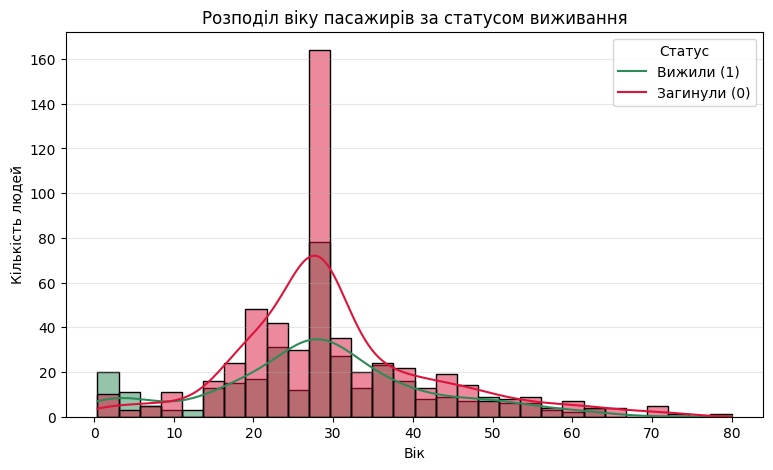

In [31]:
mean_age = df.groupby('Survived')['Age'].mean()
print("Середній вік пасажирів:")
print(f"• Загиблі (Survived = 0): {mean_age[0]:.1f} років")
print(f"• Вижили  (Survived = 1): {mean_age[1]:.1f} років\n")

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, palette={0: 'crimson', 1: 'seagreen'})
plt.title('Розподіл віку пасажирів за статусом виживання')
plt.xlabel('Вік')
plt.ylabel('Кількість людей')
plt.legend(title='Статус', labels=['Вижили (1)', 'Загинули (0)'])
plt.grid(axis='y', alpha=0.3)
plt.show()

**Аналітичний та графічний висновок:**

**Порівняння середнього віку:** Середній вік тих, хто вижив (~28.3–28.5 років), є дещо нижчим за середній вік загиблих (~30.5–30.6 років).

**Пріоритет для дітей:** Найвища ймовірність вижити спостерігається серед дітей віком до 10–12 років (працювало правило «жінки та діти в першу чергу»).

**Основна група ризику:** Найбільша смертність припадає на молодих людей працездатного віку (20–35 років) — більшість із них були чоловіками та пасажирами 3-го класу або членами екіпажу.

**Літні пасажири:** Серед осіб віком від 60 років частка тих, хто вижив, є мінімальною, оскільки евакуація вимагала фізичної сили та швидкості.

**Загальний підсумок:** Вік безпосередньо впливав на шанси виживання: нижчий середній вік серед врятованих обумовлений насамперед порятунком дітей та високою смертністю дорослих чоловіків.

In [32]:
# Clalculate survival rate per class per sex

for i in range(1, 4):
  for j in range(2):
    surv_rate = df[(df['Pclass'] == i) & (df['Sex'] == j) & (df['Survived'] == 1)].shape[0] / df[(df['Pclass'] == i) & (df['Sex'] == j)].shape[0]
    print(f'Share of survived ("male" if j == 0 else "female") passengers in class {i}: {surv_rate * 100:.2f}%')

Share of survived ("male" if j == 0 else "female") passengers in class 1: 36.89%
Share of survived ("male" if j == 0 else "female") passengers in class 1: 96.81%
Share of survived ("male" if j == 0 else "female") passengers in class 2: 15.74%
Share of survived ("male" if j == 0 else "female") passengers in class 2: 92.11%
Share of survived ("male" if j == 0 else "female") passengers in class 3: 13.54%
Share of survived ("male" if j == 0 else "female") passengers in class 3: 50.00%


18. Побудувати теплову карту коретляції

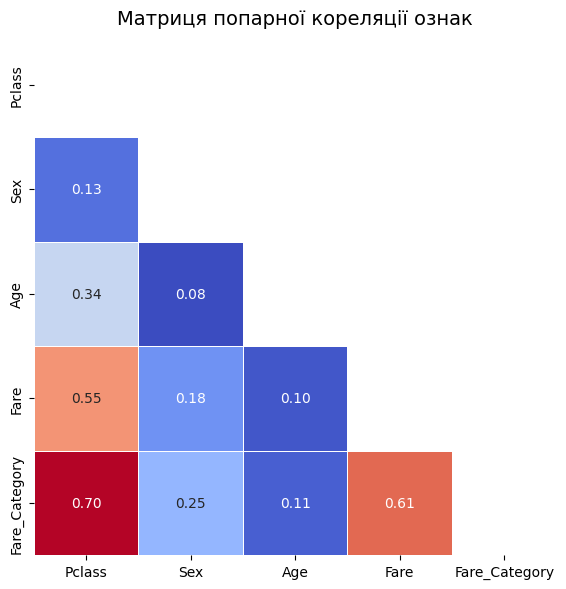

In [33]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

# Побудова теплової карти кореляції
fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)), # маскуємо верхній трикутник
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()